In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
import unsloth
from unsloth import FastLanguageModel
from peft import set_peft_model_state_dict
from huggingface_hub import hf_hub_download
def load_adapter(adapter_hub_name):
    model,tokenizer=FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-3-270m-it",
        max_seq_length=2048,
        load_in_4bit=True,
    )
    model=FastLanguageModel.get_peft_model(
        model,
        r=8,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                       "up_proj","down_proj","gate_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        seed=3407,
        use_rslora=False,
        loftq_config=None,
    )
    try:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{adapter_hub_name}",
            filename="adapter_model.safetensors",
        )
    except:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{adapter_hub_name}",
            filename="adapter_model.bin",
        )
    from safetensors.torch import load_file
    state_dict = load_file(model_weights)
    set_peft_model_state_dict(model, state_dict)
    return model

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Gemma Model trained and saved in Huggingface

Model loaded from https://huggingface.co/Srishtik

In [ ]:
model=load_adapter("gemma_adapter_unsloth_dair_ai_finetuned_500")

==((====))==  Unsloth 2026.6.1: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


model.safetensors:   0%|          | 0.00/393M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/7.63M [00:00<?, ?B/s]

In [ ]:
def find_layers(model):
    for name, module in model.named_modules():
        if hasattr(module, '__len__') and 'ModuleList' in type(module).__name__:
            print(f"Found ModuleList at: {name} | length: {len(module)}")

find_layers(model)

Found ModuleList at: base_model.model.model.layers | length: 18


## Extract LoRA Deltas

In [ ]:
print(type(model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
print(type(model.model))

<class 'transformers.models.gemma3.modeling_gemma3.Gemma3ForCausalLM'>


In [ ]:
import torch

def extract_all_deltas(model, n_blocks=18):
    deltas = {}
    for i in range(n_blocks):
        block = model.base_model.model.model.layers[i]
        block_deltas = {}
        for name, module in block.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                try:
                    A = module.lora_A.default.weight.detach().float().to_dense()
                    B = module.lora_B.default.weight.detach().float().to_dense()
                    delta_W = B @ A
                    block_deltas[name] = delta_W
                except Exception as e:
                    print(f"Block {i} | {name} | error: {e}")
        if block_deltas:
            deltas[i] = block_deltas
    return deltas

deltas = extract_all_deltas(model)


# Weight Similarity

## Cosine Similarity between layers (18 layers)

## Layer-wise Norms

In [ ]:
def frobenius_per_block(deltas):
    norms = {}
    for block_idx, block_deltas in deltas.items():
        total_norm = sum(
            delta.norm().item()
            for delta in block_deltas.values()
        )
        norms[block_idx] = total_norm
    return norms

norms = frobenius_per_block(deltas)
for block_idx, norm in sorted(norms.items()):
    print(f"Block {block_idx:2d} | Frobenius norm: {norm:.4f}")

Block  0 | Frobenius norm: 1.1207
Block  1 | Frobenius norm: 1.0596
Block  2 | Frobenius norm: 1.0777
Block  3 | Frobenius norm: 1.0822
Block  4 | Frobenius norm: 1.1309
Block  5 | Frobenius norm: 1.0519
Block  6 | Frobenius norm: 1.0857
Block  7 | Frobenius norm: 1.0943
Block  8 | Frobenius norm: 1.0695
Block  9 | Frobenius norm: 1.0599
Block 10 | Frobenius norm: 1.1639
Block 11 | Frobenius norm: 1.3487
Block 12 | Frobenius norm: 1.5517
Block 13 | Frobenius norm: 1.4848
Block 14 | Frobenius norm: 1.7301
Block 15 | Frobenius norm: 1.9159
Block 16 | Frobenius norm: 2.0855
Block 17 | Frobenius norm: 2.2528


## Singular Value

In [ ]:
def generate_response(model,tokenizer,prompt,max_new_tokens=128):
    inputs=tokenizer(prompt,return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs=model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
        generated=outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated,skip_special_tokens=True)


In [ ]:
# import re
# import json

# def extract_move(text):
#     # Try JSON parsing first
#     try:
#         parsed = json.loads(text)
#         # Handle both "missing move" and "missing_move"
#         return parsed.get("missing move") or parsed.get("missing_move")
#     except:
#         pass

#     # Fall back to regex — find a chess move pattern
#     match = re.search(r'[a-h][1-8][a-h][1-8][qrbn]?', text)
#     if match:
#         return match.group(0)

#     return text.strip()

# def evaluate_model(model, tokenizer, test_dataset, n_samples=50):
#     correct = 0
#     total = 0

#     for i,sample in enumerate(test_dataset.select(range(n_samples))):
#         print(f"Step {i}")
#         task = sample["task"]
#         inp = sample["input"]
#         expected = extract_move(sample["expected_output"].strip())

#         user_content = f"{task}\n{inp}".strip() if inp else task

#         prompt = tokenizer.apply_chat_template(
#             [{"role": "user", "content": user_content}],
#             tokenize=False,
#             add_generation_prompt=True,
#         )

#         raw_prediction = extract_move(
#             generate_response(model, tokenizer, prompt).strip()
#         )
#         prediction=extract_move(raw_prediction)
#         if i < 5:
#             print(f"--- Sample {i} ---")
#             print(f"Expected:   {expected}")
#             print(f"Raw output: {raw_prediction}")
#             print(f"Extracted:  {prediction}")
#             print(f"Match:      {prediction == expected}")
#             print()
#         if prediction == expected:
#             correct += 1
#         total += 1

#     return correct / total

In [ ]:
!pip install bitsandbytes

## SVD Analysis

In [ ]:
# SVD Analysis
def svd_analysis(deltas):
    print(f"{'Block':>6} | {'projection':20s} | {'eff_rank':>9} | {'top1%':>7} | {'max_sv':>8} | {'min_sv':>8}")
    print("-" * 75)
    for block_idx, block_deltas in sorted(deltas.items()):
        for name, delta_W in block_deltas.items():
            svs = torch.linalg.svdvals(delta_W.float())
            eff_rank    = (svs > 0.01 * svs[0]).sum().item()
            top1        = (svs[0] / svs.sum()).item()
            print(f"Block {block_idx:2d} | {name:20s} | "
                  f"{eff_rank:>9d} | "
                  f"{top1:>7.3f} | "
                  f"{svs[0].item():>8.4f} | "
                  f"{svs[-1].item():>8.4f}")

svd_analysis(deltas)

 Block | projection           |  eff_rank |   top1% |   max_sv |   min_sv
---------------------------------------------------------------------------
Block  0 | self_attn.q_proj     |         8 |   0.355 |   0.1326 |   0.0000
Block  0 | self_attn.k_proj     |         8 |   0.290 |   0.0576 |   0.0000
Block  0 | self_attn.v_proj     |         8 |   0.387 |   0.0612 |   0.0000
Block  0 | self_attn.o_proj     |         8 |   0.394 |   0.1106 |   0.0000
Block  0 | mlp.gate_proj        |         8 |   0.311 |   0.2157 |   0.0000
Block  0 | mlp.up_proj          |         8 |   0.322 |   0.1866 |   0.0000
Block  0 | mlp.down_proj        |         8 |   0.199 |   0.0676 |   0.0000
Block  1 | self_attn.q_proj     |         8 |   0.243 |   0.1015 |   0.0000
Block  1 | self_attn.k_proj     |         8 |   0.312 |   0.0579 |   0.0000
Block  1 | self_attn.v_proj     |         8 |   0.350 |   0.0587 |   0.0000
Block  1 | self_attn.o_proj     |         8 |   0.343 |   0.1031 |   0.0000
Block  1 | mlp

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [ ]:
def pairwise_cosine_svd(deltas, proj_name='self_attn.q_proj', top_k=3):
    """
    Compare the top-k singular vectors of delta_W across blocks
    rather than the full flattened matrix
    """
    block_indices = sorted(deltas.keys())

    # Get top-k left singular vectors for each block
    singular_vecs = {}
    for idx in block_indices:
        if proj_name in deltas[idx]:
            delta_W = deltas[idx][proj_name].float()
            U, S, Vh = torch.linalg.svd(delta_W, full_matrices=False)
            # U columns are left singular vectors — directions in output space
            # Take top-k most important ones
            singular_vecs[idx] = U[:, :top_k]  # [out_dim, top_k]

    available = sorted(singular_vecs.keys())
    n = len(available)

    # For each pair of blocks, compare their top singular vector
    matrix = np.zeros((n, n))
    for i, bi in enumerate(available):
        for j, bj in enumerate(available):
            # Compare top singular vectors
            vi = singular_vecs[bi][:, 0]  # top singular vector of block i
            vj = singular_vecs[bj][:, 0]  # top singular vector of block j
            sim = F.cosine_similarity(
                vi.unsqueeze(0),
                vj.unsqueeze(0)
            ).item()
            # Take absolute value — direction sign is arbitrary in SVD
            matrix[i, j] = abs(sim)

    return matrix, available

In [ ]:
def compare_input_directions(deltas, proj_name, top_k=1):
    """Compare what directions each layer reads from the stream"""
    block_indices = sorted(deltas.keys())

    input_vecs = {}
    for idx in block_indices:
        if proj_name in deltas[idx]:
            delta_W = deltas[idx][proj_name].float()
            U, S, Vh = torch.linalg.svd(delta_W, full_matrices=False)
            # Vh rows are right singular vectors — directions in input space
            input_vecs[idx] = Vh[0]  # top right singular vector

    available = sorted(input_vecs.keys())
    n = len(available)
    matrix = np.zeros((n, n))

    for i, bi in enumerate(available):
        for j, bj in enumerate(available):
            sim = abs(F.cosine_similarity(
                input_vecs[bi].unsqueeze(0),
                input_vecs[bj].unsqueeze(0)
            ).item())
            matrix[i, j] = sim

    return matrix, available

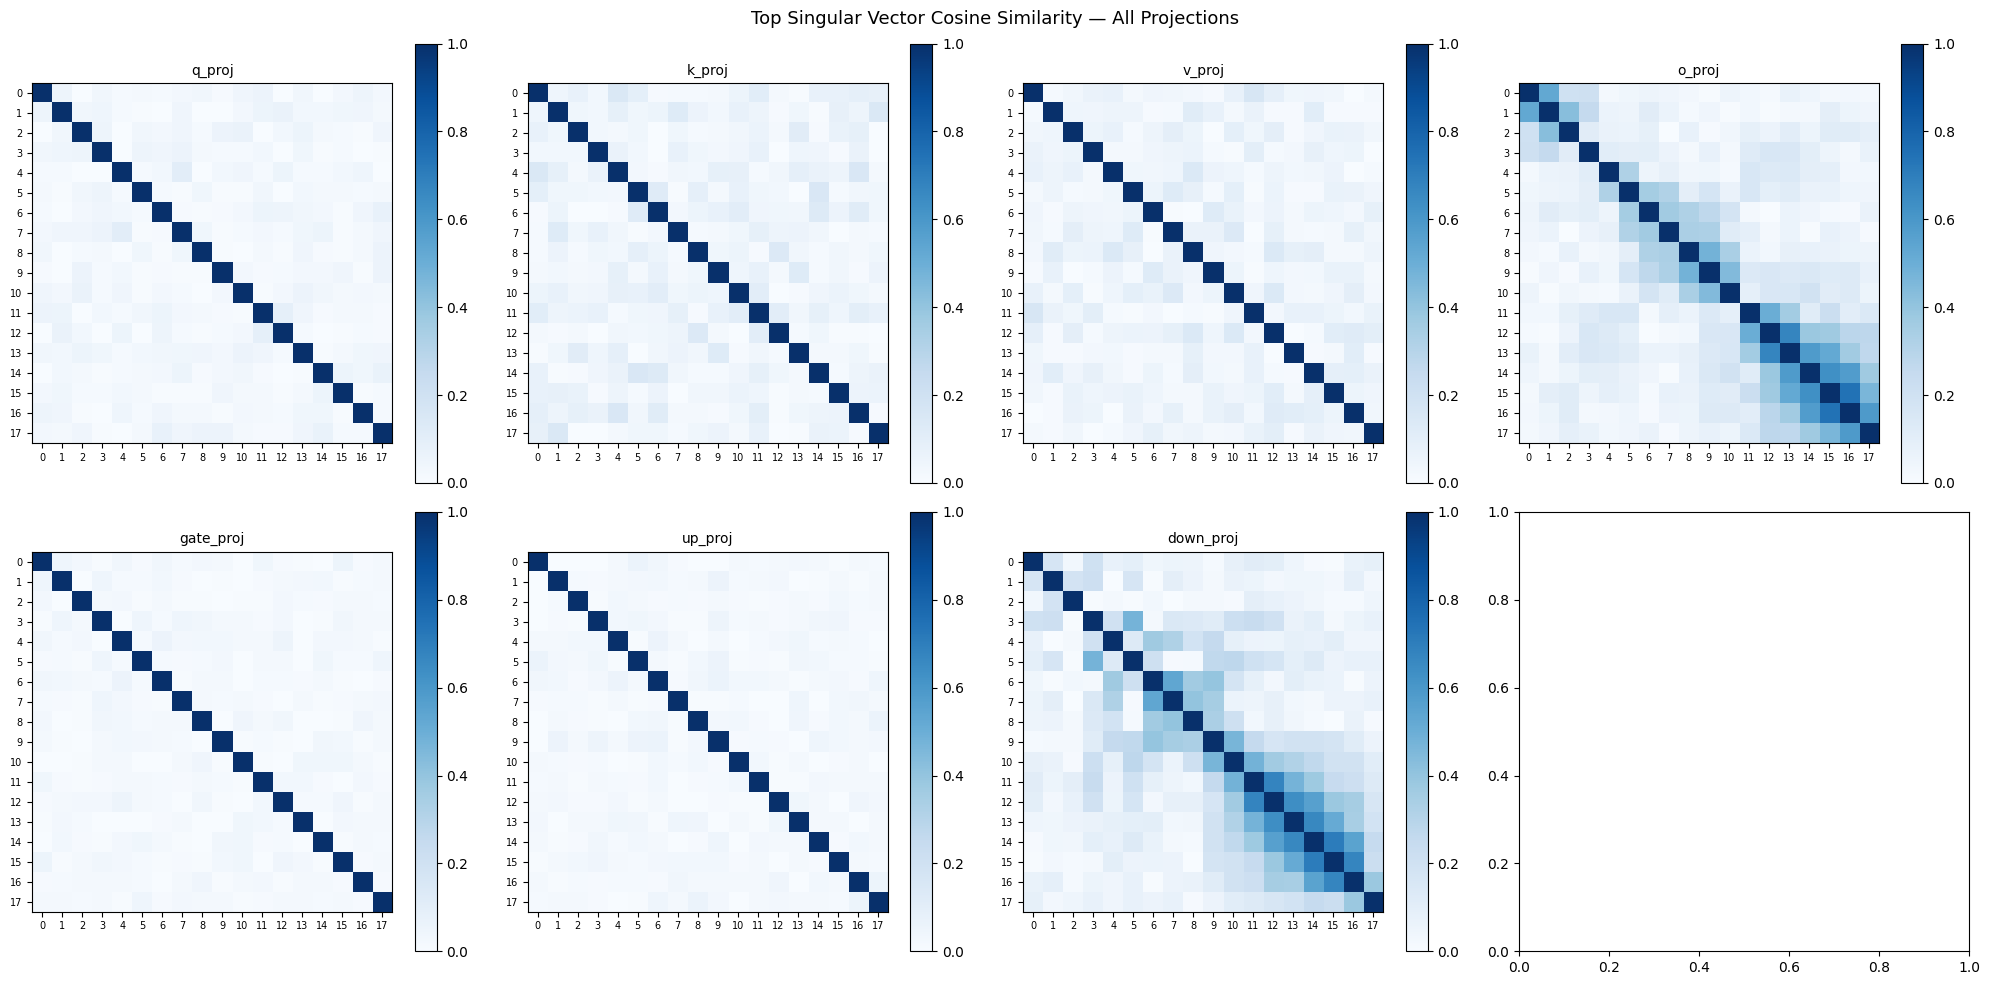

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, proj in enumerate(proj_types):
    # Use SVD-based comparison instead of full matrix
    matrix, labels = pairwise_cosine_svd(deltas, proj, top_k=1)
    ax = axes[idx]
    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(proj.split('.')[-1], fontsize=10)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax)

plt.suptitle('Top Singular Vector Cosine Similarity — All Projections', fontsize=13)
plt.tight_layout()
plt.savefig('svd_cosine_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import re

label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def extract_emotion(text):
    text = text.strip().lower()
    # Map common truncations
    if "sadness" in text or " sad" in text or text.startswith("sad"):
        return "sadness"
    if "joy" in text or "happy" in text or "happiness" in text:
        return "joy"
    if "love" in text or "loving" in text:
        return "love"
    if "anger" in text or "angry" in text or "angr" in text:
        return "anger"
    if "fear" in text or "afraid" in text or "scared" in text:
        return "fear"
    if "surprise" in text or "surprised" in text:
        return "surprise"
    return text

def generate_response(model, tokenizer, prompt, max_new_tokens=16):
    emotions = ["sadness", "joy", "love", "anger", "fear", "surprise"]
    emotion_ids = [tokenizer.encode(e, add_special_tokens=False)[0] for e in emotions]

    def only_emotions(batch_id, input_ids):
      return emotion_ids  # only allow emotion tokens at every step

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            prefix_allowed_tokens_fn=only_emotions,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

In [ ]:
def evaluate_model_batched(model, tokenizer, test_data, n_samples=100, batch_size=16):
    correct = 0
    samples = test_data.select(range(n_samples))

    all_prompts = []
    all_expected = []

    for sample in samples:
        expected = label_map[sample["label"]]
        prompt = tokenizer.apply_chat_template(
            [{
                "role": "user",
                "content": f"Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.Give me only the emotion\n\nText: {sample['text']}"
            }],
            tokenize=False,
            add_generation_prompt=True,
        )
        all_prompts.append(prompt)
        all_expected.append(expected)

    for i in range(0, n_samples, batch_size):
        print(f"Batch {i//batch_size + 1}/{n_samples//batch_size}")  # progress
        batch_prompts  = all_prompts[i:i+batch_size]
        batch_expected = all_expected[i:i+batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=256,
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=8,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id else tokenizer.eos_token_id,
                forced_eos_token_id=tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        for j, (output, expected) in enumerate(zip(outputs, batch_expected)):
                # Find actual end of this prompt using attention mask
                actual_input_len = inputs["attention_mask"][j].sum().item()
                generated = tokenizer.decode(
                    output[actual_input_len:], skip_special_tokens=True
                ).strip()
                prediction = extract_emotion(generated)
                if i + j < 5:
                        print(f"Expected: {expected} | Predicted: {prediction} | Match: {prediction == expected}")

                if prediction == expected:
                        correct += 1

    accuracy = correct / n_samples
    print(f"\nAccuracy: {accuracy:.4f}")
    return accuracy

In [ ]:
base_model,tokenizer=FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-3-270m-it",
    max_seq_length=2048,
    load_in_4bit=True,
)

base_model=FastLanguageModel.get_peft_model(
        base_model,
        r=8,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                       "up_proj","down_proj","gate_proj"],
        lora_alpha=16,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        seed=3407,
        use_rslora=False,
        loftq_config=None,
    )

==((====))==  Unsloth 2026.5.10: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [ ]:
import copy

import copy

def build_ablated_model(base_model, adapter_deltas, ablate_block=None):
    model = copy.deepcopy(base_model)
    applied = 0

    with torch.no_grad():
        for name, module in model.named_modules():
            # Only process LoRA wrapped layers
            if not (hasattr(module, 'lora_A') and hasattr(module, 'lora_B')):
                continue

            if name not in adapter_deltas:
                continue

            if ablate_block is not None:
                if f"layers.{ablate_block}." in name:
                    continue

            delta = adapter_deltas[name].to(next(module.parameters()).device)

            # Decompose delta back into A and B using SVD
            # delta = B @ A, so we inject it via lora_A and lora_B
            U, S, Vh = torch.linalg.svd(delta.float(), full_matrices=False)
            rank = module.lora_A['default'].weight.shape[0]

            # Take top-r components
            U_r = U[:, :rank]
            S_r = S[:rank]
            Vh_r = Vh[:rank, :]

            # Set lora_B = U_r * sqrt(S_r), lora_A = sqrt(S_r) * Vh_r
            sqrt_S = torch.sqrt(S_r)
            new_B = (U_r * sqrt_S.unsqueeze(0)).to(module.lora_B['default'].weight.dtype)
            new_A = (Vh_r * sqrt_S.unsqueeze(1)).to(module.lora_A['default'].weight.dtype)

            module.lora_B['default'].weight.data = new_B
            module.lora_A['default'].weight.data = new_A

            # Set scaling
            module.scaling['default'] = 1.0

            applied += 1

    print(f"Applied {applied} deltas out of {len(adapter_deltas)} available")
    return model



def run_ablation(base_model, adapter_deltas, tokenizer, test_dataset, n_samples=100):
    results = {}

    # Base model
    print("Evaluating base model...")
    FastLanguageModel.for_inference(base_model)
    results["base"] = evaluate_model_batched(base_model, tokenizer, test_dataset, n_samples)
    print(f"Base: {results['base']:.4f}")

    # Fully fine-tuned
    print("Evaluating fully fine-tuned model...")
    full_model = build_ablated_model(base_model, adapter_deltas, ablate_block=None)
    FastLanguageModel.for_inference(full_model)
    results["finetuned"] = evaluate_model_batched(full_model, tokenizer, test_dataset, n_samples)
    print(f"Finetuned: {results['finetuned']:.4f}")
    del full_model
    torch.cuda.empty_cache()

    # Ablate one block at a time
    for block_id in range(28):
        print(f"Ablating block {block_id}...")

        ablated = build_ablated_model(base_model, adapter_deltas, ablate_block=block_id)
        FastLanguageModel.for_inference(ablated)
        score = evaluate_model_batched(ablated, tokenizer, test_dataset, n_samples)
        results[f"block_{block_id}"] = score

        drop = results["finetuned"] - score
        print(f"Block {block_id}: {score:.4f}  drop: {drop:+.4f}")

        del ablated
        torch.cuda.empty_cache()

    return results


def plot_ablation(results):
    block_ids = list(range(28))
    scores = [results[f"block_{i}"] for i in block_ids]
    drops = [results["finetuned"] - s for s in scores]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    ax1.plot(block_ids, scores, marker="o", color="steelblue", label="Ablated")
    ax1.axhline(results["finetuned"], color="green", linestyle="--", label="Finetuned")
    ax1.axhline(results["base"], color="red", linestyle="--", label="Base model")
    ax1.set_ylabel("Accuracy")
    ax1.set_title("Layer Ablation — Single Adapter")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    colors = ["red" if d > 0 else "limegreen" for d in drops]
    ax2.bar(block_ids, drops, color=colors)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Ablated Block")
    ax2.set_ylabel("Performance Drop")
    ax2.set_title("Impact per Block (red = important, green = ablating helps)")
    ax2.set_xticks(block_ids)
    ax2.set_xticklabels([f"b{i}" for i in block_ids], rotation=45)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("ablation_single_adapter.png")
    plt.show()

In [ ]:
import copy

def build_ablated_model(base_model, adapter_deltas, ablate_block:list[int]):
    model = copy.deepcopy(base_model)
    applied = 0

    with torch.no_grad():
        for name, module in model.named_modules():
            # Only process LoRA wrapped layers
            if not (hasattr(module, 'lora_A') and hasattr(module, 'lora_B')):
                continue

            if name not in adapter_deltas:
                continue
            # if ablate_block:
            #   for block in ablate_block:
            #        if f"layers.{block}." in name:
            #           print(f"Layer {block} ablated")
            #   continue
            if any(f"layers.{block}." in name for block in ablate_block):
              continue

            delta = adapter_deltas[name].to(next(module.parameters()).device)

            # Decompose delta back into A and B using SVD
            # delta = B @ A, so we inject it via lora_A and lora_B
            U, S, Vh = torch.linalg.svd(delta.float(), full_matrices=False)
            rank = module.lora_A['default'].weight.shape[0]

            # Take top-r components
            U_r = U[:, :rank]
            S_r = S[:rank]
            Vh_r = Vh[:rank, :]

            # Set lora_B = U_r * sqrt(S_r), lora_A = sqrt(S_r) * Vh_r
            sqrt_S = torch.sqrt(S_r)
            new_B = (U_r * sqrt_S.unsqueeze(0)).to(module.lora_B['default'].weight.dtype)
            new_A = (Vh_r * sqrt_S.unsqueeze(1)).to(module.lora_A['default'].weight.dtype)

            module.lora_B['default'].weight.data = new_B
            module.lora_A['default'].weight.data = new_A

            # Set scaling
            module.scaling['default'] = 1.0

            applied += 1

    print(f"Applied {applied} deltas out of {len(adapter_deltas)} available")
    return model

def run_ablation(base_model, adapter_deltas, tokenizer, test_dataset,ablate_block:list[int], n_samples=100):
    results = {}

    # Base model
    print("Evaluating base model...")
    FastLanguageModel.for_inference(base_model)
    results["base"] = evaluate_model_batched(base_model, tokenizer, test_dataset, n_samples)
    print(f"Base: {results['base']:.4f}")

    # Fully fine-tuned
    print("Evaluating fully fine-tuned model...")
    full_model = build_ablated_model(base_model, adapter_deltas, [])
    FastLanguageModel.for_inference(full_model)
    results["finetuned"] = evaluate_model_batched(full_model, tokenizer, test_dataset, n_samples)
    print(f"Finetuned: {results['finetuned']:.4f}")
    del full_model
    torch.cuda.empty_cache()

    # Ablate one block at a time
    ablated = build_ablated_model(base_model, adapter_deltas, ablate_block)
    FastLanguageModel.for_inference(ablated)
    score = evaluate_model_batched(ablated, tokenizer, test_dataset, n_samples)
    results["block"] = score

    drop = results["finetuned"] - score
    print(f"Blocks {ablate_block} ablated")
    print(f"Block: {score:.4f}  drop: {drop:+.4f}")

    del ablated
    torch.cuda.empty_cache()

    return results



# Ablation of combination of layers

In [ ]:
def run_ablation(base_model, adapter_deltas, tokenizer, test_dataset,ablate_block:list[int], n_samples=100):
    results = {}

    # Base model
    # print("Evaluating base model...")
    # FastLanguageModel.for_inference(base_model)
    # results["base"] = evaluate_model_batched(base_model, tokenizer, test_dataset, n_samples)
    # print(f"Base: {results['base']:.4f}")

    # Fully fine-tuned
    # print("Evaluating fully fine-tuned model...")
    # full_model = build_ablated_model(base_model, adapter_deltas, [])
    # FastLanguageModel.for_inference(full_model)
    # results["finetuned"] = evaluate_model_batched(full_model, tokenizer, test_dataset, n_samples)
    # print(f"Finetuned: {results['finetuned']:.4f}")
    # del full_model
    # torch.cuda.empty_cache()
    results["finetuned"]=0.65
    # Ablate one block at a time
    ablated = build_ablated_model(base_model, adapter_deltas, ablate_block)
    FastLanguageModel.for_inference(ablated)
    score = evaluate_model_batched(ablated, tokenizer, test_dataset, n_samples)
    results["block"] = score

    drop = results["finetuned"] - score
    print(f"Blocks {ablate_block} ablated")
    print(f"Block: {score:.4f}  drop: {drop:+.4f}")

    del ablated
    torch.cuda.empty_cache()

    return results


In [ ]:
from datasets import load_dataset
test_dataset = load_dataset("dair-ai/emotion", split = "test[:10000]")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
ablate_block=[2,9]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness

In [ ]:
ablate_block=[0,1,5,6,7,16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 84 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness 

In [ ]:
ablate_block=[3,4,8,10,11,12,13,14,15,17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 56 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness 

In [ ]:
ablate_block=[3,4,8,10,11,12,13,14,15]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 63 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: fear | Match: False
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.3300
Blocks [3, 4, 8, 10, 11, 12, 13, 14, 15] ablated
Block: 0.3300  drop: +0.3200


In [ ]:
ablate_block=[3,8,10,11,12,13,14,15]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 70 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.3900
Blocks [3, 8, 10, 11, 12, 13, 14, 15] ablated
Block: 0.3900  drop: +0.2600


In [ ]:
ablate_block=[4,8,10,11,12,13,14,15]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 70 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.3800
Blocks [4, 8, 10, 11, 12, 13, 14, 15] ablated
Block: 0.3800  drop: +0.2700


In [ ]:
ablate_block=[8,10,11,12,13,14,15]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 77 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.4800
Blocks [8, 10, 11, 12, 13, 14, 15] ablated
Block: 0.4800  drop: +0.1700


In [ ]:
ablate_block=[3,8,10,11,12,13,14,15,17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 63 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.4000
Blocks [3, 8, 10, 11, 12, 13, 14, 15, 17] ablated
Block: 0.4000  drop: +0.2500


In [ ]:
ablate_block=[4,8,10,11,12,13,14,15,17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 63 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.3800
Blocks [4, 8, 10, 11, 12, 13, 14, 15, 17] ablated
Block: 0.3800  drop: +0.2700


In [ ]:
ablate_block=[2,9,17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 105 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6300
Blocks [2, 9, 17] ablated
Block: 0.6300  drop: +0.0200


In [ ]:
ablate_block=[2,9,10]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 105 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6300
Blocks [2, 9, 10] ablated
Block: 0.6300  drop: +0.0200


In [ ]:
ablate_block=[8,10,11,12,13,14,15,17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 70 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.4400
Blocks [8, 10, 11, 12, 13, 14, 15, 17] ablated
Block: 0.4400  drop: +0.2100


In [ ]:
ablate_block=[17]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 119 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6100
Blocks [17] ablated
Block: 0.6100  drop: +0.0400


In [ ]:
ablate_block=[0,1,2,5,6,7,9,16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 70 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.5400
Blocks [0, 1, 2, 5, 6, 7, 9, 16] ablated
Block: 0.5400  drop: +0.1100


In [ ]:
ablate_block=[0,1,5,6,7]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 91 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness 

In [ ]:
ablate_block=[16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 119 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness

In [ ]:
ablate_block=[5,7]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness

In [ ]:
ablate_block=[1,5]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness

In [ ]:
ablate_block=[5,6]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Blocks [5, 6] ablated
Block: 0.6500  drop: +0.0000


In [ ]:
ablate_block=[0,5]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness

In [ ]:
ablate_block=[2,9]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6700
Blocks [2, 9] ablated
Block: 0.6700  drop: -0.0200


In [ ]:
ablate_block=[1,6]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Blocks [1, 6] ablated
Block: 0.6500  drop: +0.0000


In [ ]:
ablate_block=[5,16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6600
Blocks [5, 16] ablated
Block: 0.6600  drop: -0.0100


In [ ]:
ablate_block=[2,5,9,16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 98 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6200
Blocks [2, 5, 9, 16] ablated
Block: 0.6200  drop: +0.0300


In [ ]:
ablate_block=[2,5]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Blocks [2, 5] ablated
Block: 0.6500  drop: +0.0000


In [ ]:
ablate_block=[2,16]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6400
Blocks [2, 16] ablated
Block: 0.6400  drop: +0.0100


In [ ]:
ablate_block=[0,1,6,7]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 98 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6300
Blocks [0, 1, 6, 7] ablated
Block: 0.6300  drop: +0.0200


In [ ]:
ablate_block=[5,9]
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

Applied 112 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: sadness | Match: True
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6600
Blocks [5, 9] ablated
Block: 0.6600  drop: -0.0100


In [ ]:
ablate_block=[0,1,5,6,7,16]

In [ ]:
from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    # range(len(s) + 1) covers lengths from 0 up to the full list size
    return chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))

result = list(powerset(ablate_block))
print(result)


[(), (0,), (1,), (5,), (6,), (7,), (16,), (0, 1), (0, 5), (0, 6), (0, 7), (0, 16), (1, 5), (1, 6), (1, 7), (1, 16), (5, 6), (5, 7), (5, 16), (6, 7), (6, 16), (7, 16), (0, 1, 5), (0, 1, 6), (0, 1, 7), (0, 1, 16), (0, 5, 6), (0, 5, 7), (0, 5, 16), (0, 6, 7), (0, 6, 16), (0, 7, 16), (1, 5, 6), (1, 5, 7), (1, 5, 16), (1, 6, 7), (1, 6, 16), (1, 7, 16), (5, 6, 7), (5, 6, 16), (5, 7, 16), (6, 7, 16), (0, 1, 5, 6), (0, 1, 5, 7), (0, 1, 5, 16), (0, 1, 6, 7), (0, 1, 6, 16), (0, 1, 7, 16), (0, 5, 6, 7), (0, 5, 6, 16), (0, 5, 7, 16), (0, 6, 7, 16), (1, 5, 6, 7), (1, 5, 6, 16), (1, 5, 7, 16), (1, 6, 7, 16), (5, 6, 7, 16), (0, 1, 5, 6, 7), (0, 1, 5, 6, 16), (0, 1, 5, 7, 16), (0, 1, 6, 7, 16), (0, 5, 6, 7, 16), (1, 5, 6, 7, 16), (0, 1, 5, 6, 7, 16)]


In [ ]:
type(result[0])

tuple

# Ablation on combination of layers

In [ ]:
def run_ablation(base_model, adapter_deltas, tokenizer, test_dataset, result: list, n_samples=100):
    results = {}
    results["finetuned"] = 0.65

    for ablate_block in result:
        ablated = build_ablated_model(base_model, adapter_deltas, ablate_block)
        FastLanguageModel.for_inference(ablated)
        score = evaluate_model_batched(ablated, tokenizer, test_dataset, n_samples)

        key = str(ablate_block)  # e.g. "[2, 9]" or "3" as string key
        results[key] = score

        drop = results["finetuned"] - score
        print(f"Blocks {ablate_block} ablated")
        print(f"Block: {score:.4f}  drop: {drop:+.4f}")

        del ablated
        torch.cuda.empty_cache()

    return results

In [ ]:
results=run_ablation(base_model,finetuned_deltas,tokenizer,test_dataset,ablate_block,n_samples=100)

TypeError: 'int' object is not iterable

In [ ]:
# Check delta keys
print("=== Delta keys (first 3) ===")
for k in list(finetuned_deltas.keys())[:3]:
    print(k)

print("\n=== Base model param names (first 10) ===")
for name, _ in base_model.named_parameters():
    print(name)
    break  # just first one to see the pattern

=== Delta keys (first 3) ===
base_model.model.model.layers.0.self_attn.q_proj
base_model.model.model.layers.0.self_attn.k_proj
base_model.model.model.layers.0.self_attn.v_proj

=== Base model param names (first 10) ===
base_model.model.model.embed_tokens.weight


In [ ]:
for name, param in base_model.named_parameters():
    if "q_proj" in name:
        print(name)

base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.1.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.2.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.3.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.3.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.3.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.4.self_attn.q_proj.base_layer.weight
base_model.model.model.layers.4.self_attn.q_proj.lora_A.default.weight
base_model.model.model.lay

Evaluating base model...
Batch 1/6
Expected: sadness | Predicted: fear | Match: False
Expected: sadness | Predicted: joy | Match: False
Expected: sadness | Predicted: don t ever want her to feel like i m ashamed with her
model
this text expresses a strong, underlying | Match: False
Expected: joy | Predicted: sadness | Match: False
Expected: sadness | Predicted: fear | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.2000
Base: 0.2000
Evaluating fully fine-tuned model...
Applied 126 deltas out of 126 available
Batch 1/6
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: sadness | Predicted: sadness | Match: True
Expected: joy | Predicted: joy | Match: True
Expected: sadness | Predicted: joy | Match: False
Batch 2/6
Batch 3/6
Batch 4/6
Batch 5/6
Batch 6/6
Batch 7/6

Accuracy: 0.6500
Finetuned: 0.6500
Ablating block 0...
Applied 119 deltas out of 126 available
Batch 1/6
Expected: sadness 

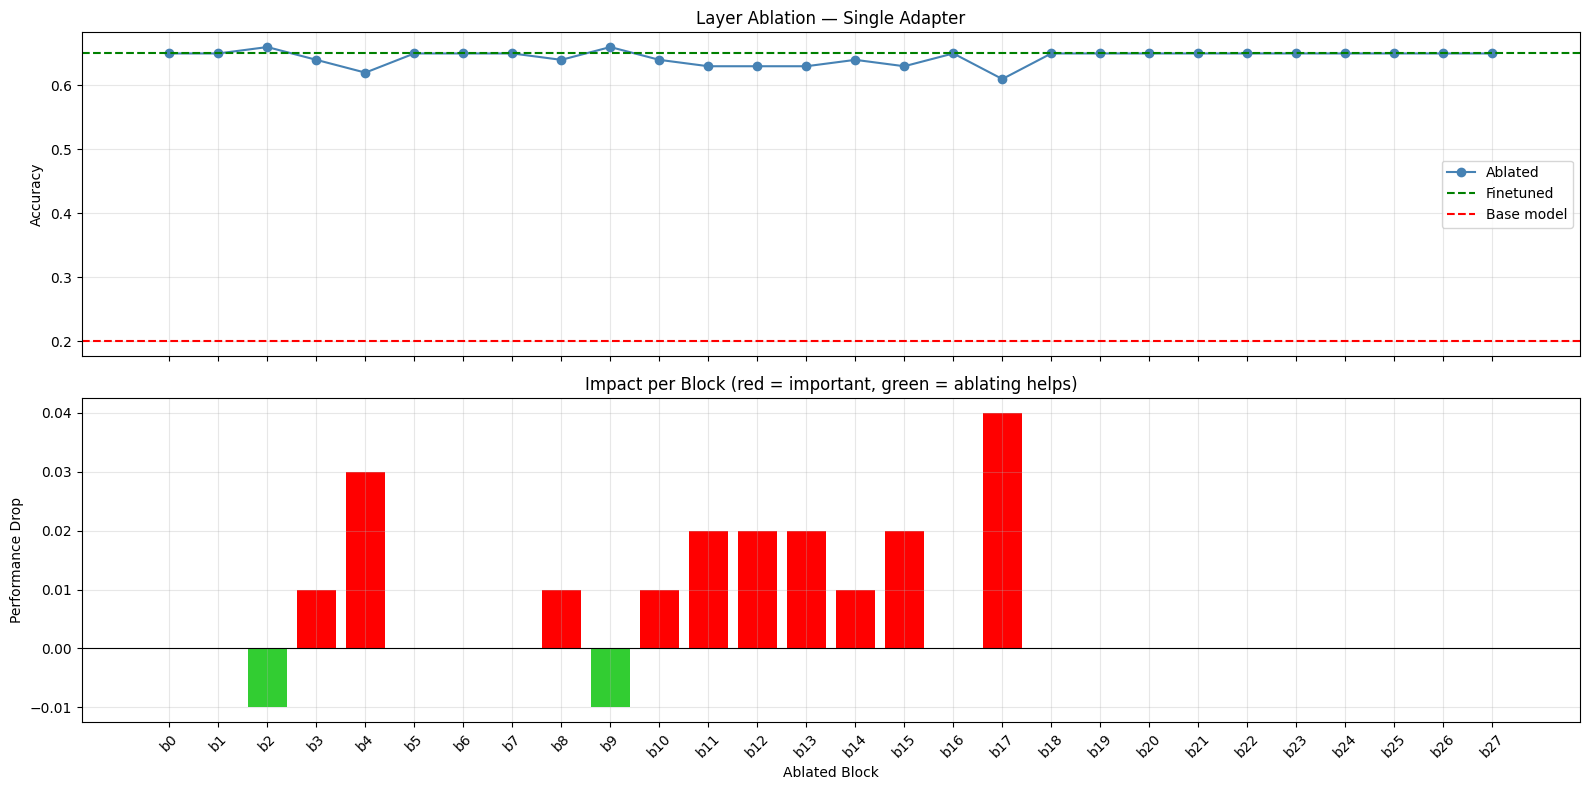

In [ ]:
# Pick one adapter to study
results1 = run_ablation(
    base_model,
    finetuned_deltas,
    tokenizer,
    test_dataset,
    n_samples=100
)

plot_ablation(results1)